In [ ]:
import pandas as pd
df = pd.read_excel('/content/data_cts_violent_and_sexual_crime.xlsx')

print(df.head())

  Violent Crime & Sexual Violence       Unnamed: 1 Unnamed: 2  \
0                             NaN              NaN        NaN   
1                          Region        Subregion    Country   
2                          Africa  Northern Africa    Algeria   
3                          Africa  Northern Africa    Algeria   
4                          Africa  Northern Africa    Algeria   

                                          Unnamed: 3 Unnamed: 4 Unnamed: 5  
0                                                NaN        NaN        NaN  
1                                           Category   variable      value  
2  Acts intended to induce fear or emotional dist...       2016        NaN  
3  Acts intended to induce fear or emotional dist...       2016        NaN  
4                                         Kidnapping       2016        NaN  


# **Data Cleaning**

## Display second row as heading and drop rows with na values

In [ ]:
df.columns = df.iloc[1]
df = df[2:]
df = df.reset_index(drop=True)


In [ ]:
print(df.head())

1  Region        Subregion  Country  \
0  Africa  Northern Africa  Algeria   
1  Africa  Northern Africa  Algeria   
2  Africa  Northern Africa  Algeria   
3  Africa  Northern Africa  Algeria   
4  Africa  Northern Africa  Algeria   

1                                           Category variable value  
0  Acts intended to induce fear or emotional dist...     2016   NaN  
1  Acts intended to induce fear or emotional dist...     2016   NaN  
2                                         Kidnapping     2016   NaN  
3                                            Robbery     2016   NaN  
4                                    Serious assault     2016   NaN  


In [ ]:
df = df.dropna()

In [ ]:
display(df)

1,Region,Subregion,Country,Category,variable,value
12,Africa,Northern Africa,Morocco,Kidnapping,2016,520
13,Africa,Northern Africa,Morocco,Robbery,2016,"18,595"
14,Africa,Northern Africa,Morocco,Serious assault,2016,"64,657"
16,Africa,Northern Africa,Morocco,Sexual violence,2016,"2,819"
17,Africa,Northern Africa,Morocco,Sexual violence: Other acts of sexual violence,2016,159
...,...,...,...,...,...,...
9319,Oceania,Australia and New Zealand,Australia,Serious assault,2024,"82,820"
9320,Oceania,Australia and New Zealand,Australia,Sexual Exploitation,2024,"1,702"
9321,Oceania,Australia and New Zealand,Australia,Sexual violence,2024,"40,087"
9331,Oceania,Melanesia,Fiji,Kidnapping,2024,2


# **Data Analysis**

## Display total violent and sexual crimes


## Total Victims by Region

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert 'value' column to numeric, handling potential commas
df['value'] = df['value'].astype(str).str.replace(',', '', regex=False)
df['value'] = pd.to_numeric(df['value'], errors='coerce')

# Drop rows where 'value' became NaN after conversion
df.dropna(subset=['value'], inplace=True)

# Compute sum of 'value' per subregion
region_counts = (
    df.groupby("Region")["value"]
    .sum()
    .reset_index()
)
region_counts.columns = ["Region", "Total_Value"]

# Sort largest to smallest
region_counts = region_counts.sort_values(by="Total_Value", ascending=False)



,Region,Total_Value
1,Americas,"41,302,150"
3,Europe,"21,969,689"
2,Asia,"3,361,460"
0,Africa,"2,817,759"
4,Oceania,"1,513,113"


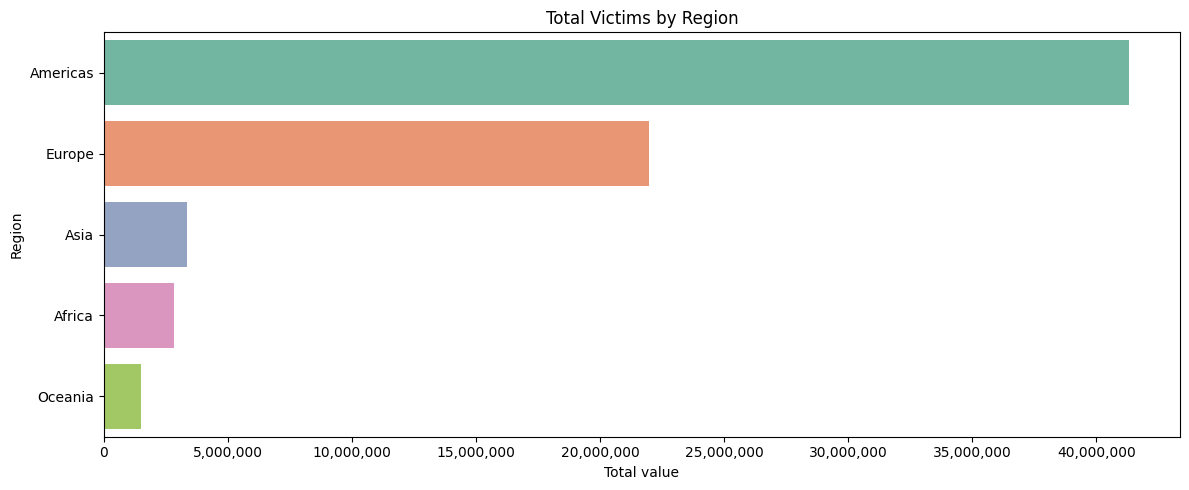

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Print table of total value per region with comma formatting
display(region_counts.style.format({'Total_Value': '{:,.0f}'}))

# bar plot
plt.figure(figsize=(12, 5))
ax = sns.barplot(
    data=region_counts,
    y= "Region",
    x= "Total_Value",
    hue="Region",
    palette="Set2",
    legend=False
)

# Format x-axis labels to display real numbers with commas
formatter = mticker.FormatStrFormatter('%1.0f') # Display as integer
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title("Total Victims by Region")
plt.xlabel("Total value")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

## Display victims per subregion

,Subregion,Total_Value
4,Latin America and the Caribbean,"28,196,742"
7,Northern America,"13,105,408"
14,Western Europe,"10,412,888"
8,Northern Europe,"8,351,696"
11,Southern Europe,"2,010,004"
12,Sub-Saharan Africa,"1,810,582"
0,Australia and New Zealand,"1,494,782"
3,Eastern Europe,"1,195,101"
6,Northern Africa,"1,007,177"
2,Eastern Asia,"955,846"


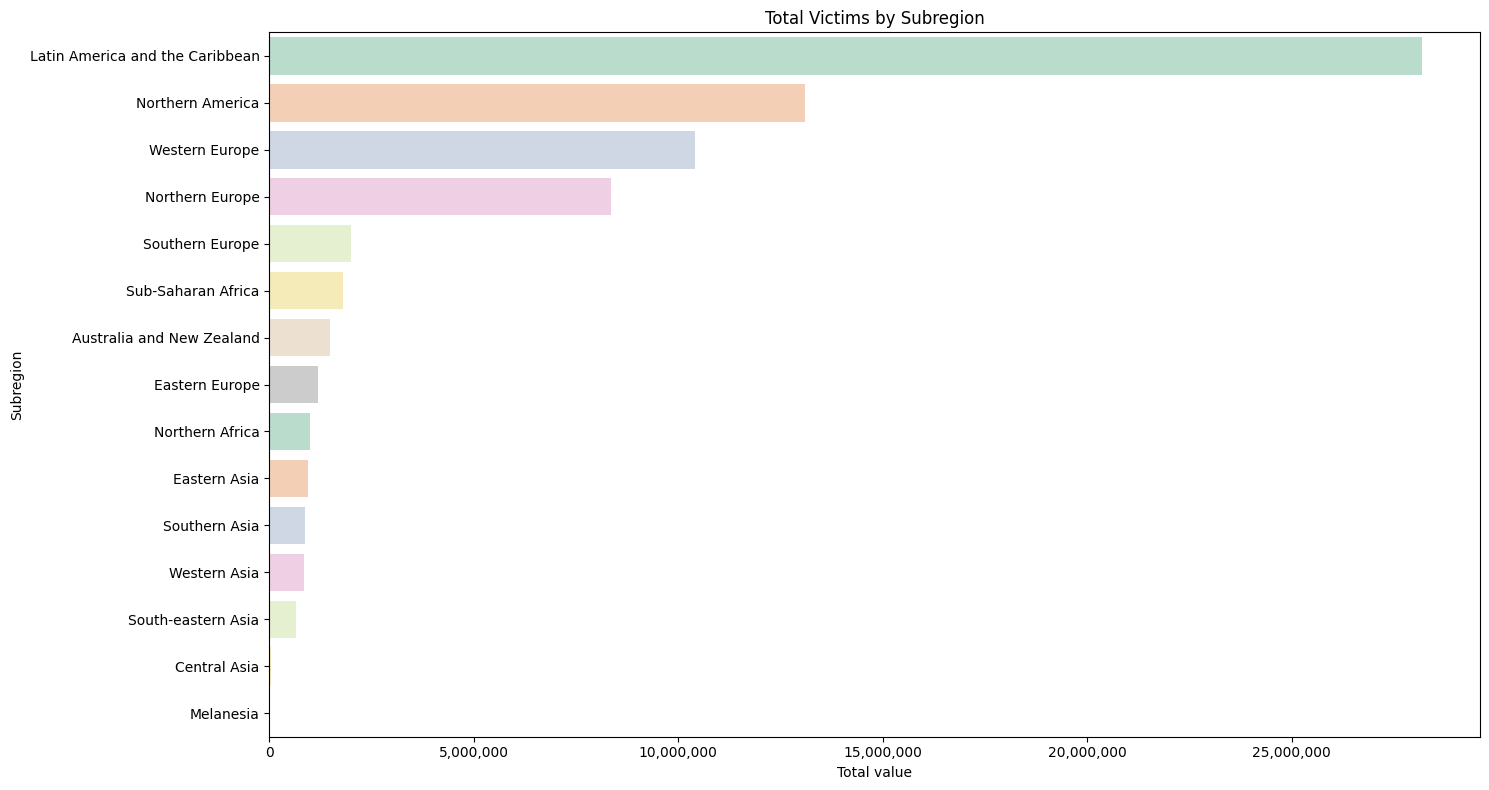

In [ ]:
# Compute sum of 'value' per subregion
subregion_counts = (
    df.groupby("Subregion")["value"]
    .sum()
    .reset_index()
)
subregion_counts.columns = ["Subregion", "Total_Value"]

# Sort largest to smallest
subregion_counts = subregion_counts.sort_values(by="Total_Value", ascending=False)

# Print table of total value per subregion with comma formatting
display(subregion_counts.style.format({'Total_Value': '{:,.0f}'}))

# bar plot
plt.figure(figsize=(15, 8))
ax = sns.barplot(
    data=subregion_counts,
    y= "Subregion",
    x= "Total_Value",
    hue="Subregion",
    palette="Pastel2",
    legend=False
)

# Format x-axis labels to display real numbers with commas
formatter = mticker.FormatStrFormatter('%1.0f') # Display as integer
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title("Total Victims by Subregion")
plt.xlabel("Total value")
plt.ylabel("Subregion")
plt.tight_layout()
plt.show()

## Display victims per each category

In [ ]:
# Display victims per each category
# Compute sum of 'value' per category
category_counts = (
    df.groupby("Category")["value"]
    .sum()
    .reset_index()
)
category_counts.columns = ["Category", "Total_Value"]

# Sort largest to smallest
category_counts = category_counts.sort_values(by="Total_Value", ascending=False)


,Category,Total_Value
4,Serious assault,"28,341,950"
3,Robbery,"20,469,770"
6,Sexual violence,"6,918,919"
0,Acts intended to induce fear or emotional distress,"5,105,360"
8,Sexual violence: Rape,"4,088,247"
9,Sexual violence: Sexual assault,"3,227,268"
5,Sexual Exploitation,"981,142"
2,Kidnapping,"666,229"
7,Sexual violence: Other acts of sexual violence,"608,790"
1,Acts intended to induce fear or emotional distress: Cyber-related,"556,496"


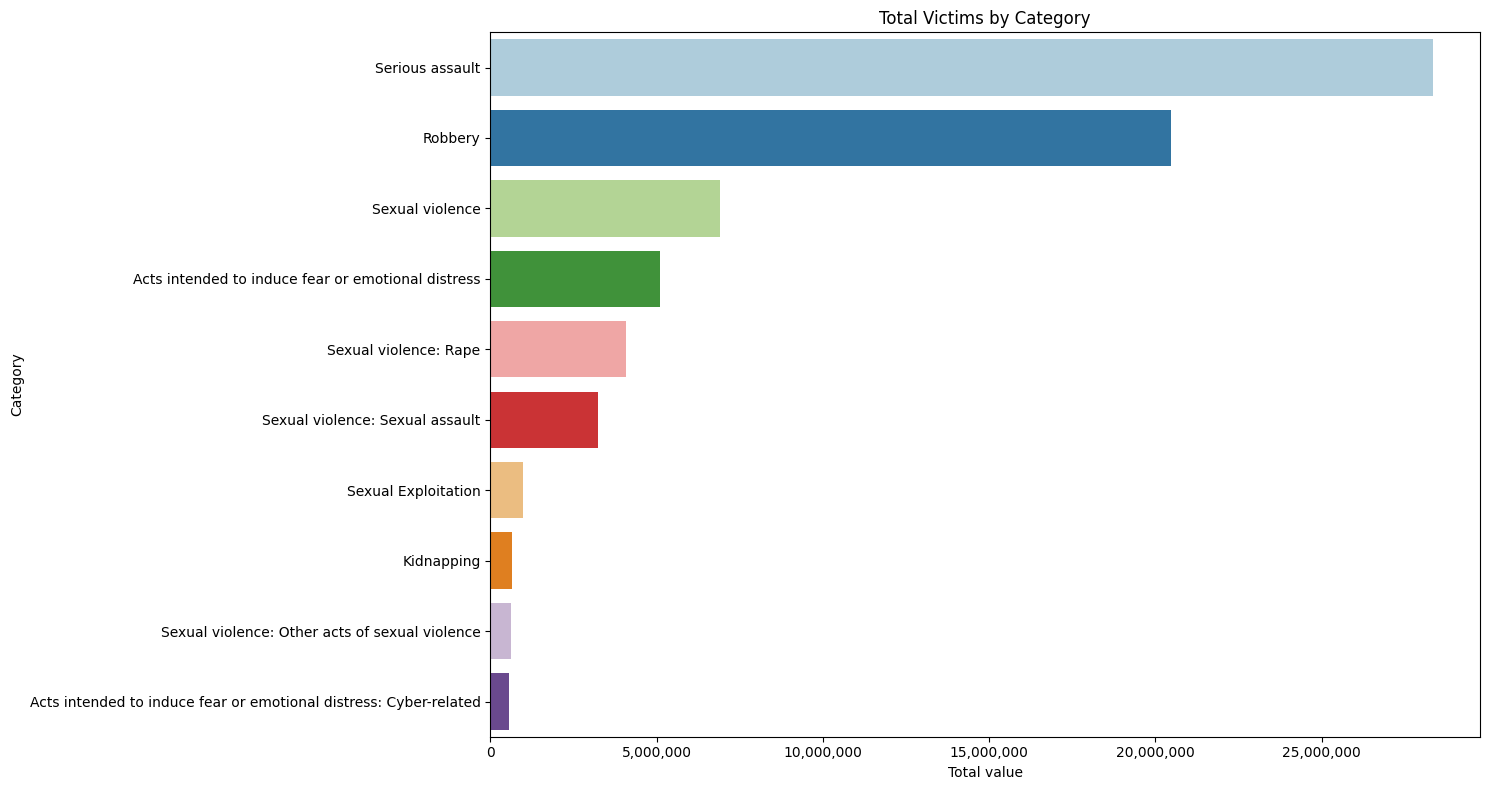

In [ ]:
# Print table of total value per subregion with comma formatting
display(category_counts.style.format({'Total_Value': '{:,.0f}'}))

# bar plot
plt.figure(figsize=(15, 8))
ax = sns.barplot(
    data=category_counts,
    y= "Category",
    x= "Total_Value",
    hue="Category",
    palette="Paired",
    legend=False
)

# Format x-axis labels to display real numbers with commas
formatter = mticker.FormatStrFormatter('%1.0f') # Display as integer
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title("Total Victims by Category")
plt.xlabel("Total value")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

## Display victims per region and per each category

In [ ]:
# Display victims per region and per each category
# Compute sum of 'value' per category
regcat_counts = (
    df.groupby(["Category","Region"])["value"]
    .sum()
    .reset_index()
)
regcat_counts.columns = ["Category","Region", "Total_Value"]

# Sort largest to smallest
regcat_counts = regcat_counts.sort_values(by="Total_Value", ascending=False)

# Print table of total value per subregion with comma formatting
display(regcat_counts.style.format({'Total_Value': '{:,.0f}'}))

,Category,Region,Total_Value
15,Robbery,Americas,"16,057,550"
20,Serious assault,Americas,"15,411,881"
22,Serious assault,Europe,"9,333,973"
32,Sexual violence,Europe,"3,207,213"
17,Robbery,Europe,"3,047,650"
30,Sexual violence,Americas,"2,626,231"
40,Sexual violence: Rape,Americas,"2,497,046"
3,Acts intended to induce fear or emotional distress,Europe,"2,401,080"
1,Acts intended to induce fear or emotional distress,Americas,"2,294,225"
47,Sexual violence: Sexual assault,Europe,"1,591,337"


## Top 10 categories with highest total victims per region

,Category,Region,Total_Value
15,Robbery,Americas,"16,057,550"
20,Serious assault,Americas,"15,411,881"
22,Serious assault,Europe,"9,333,973"
32,Sexual violence,Europe,"3,207,213"
17,Robbery,Europe,"3,047,650"
30,Sexual violence,Americas,"2,626,231"
40,Sexual violence: Rape,Americas,"2,497,046"
3,Acts intended to induce fear or emotional distress,Europe,"2,401,080"
1,Acts intended to induce fear or emotional distress,Americas,"2,294,225"
47,Sexual violence: Sexual assault,Europe,"1,591,337"


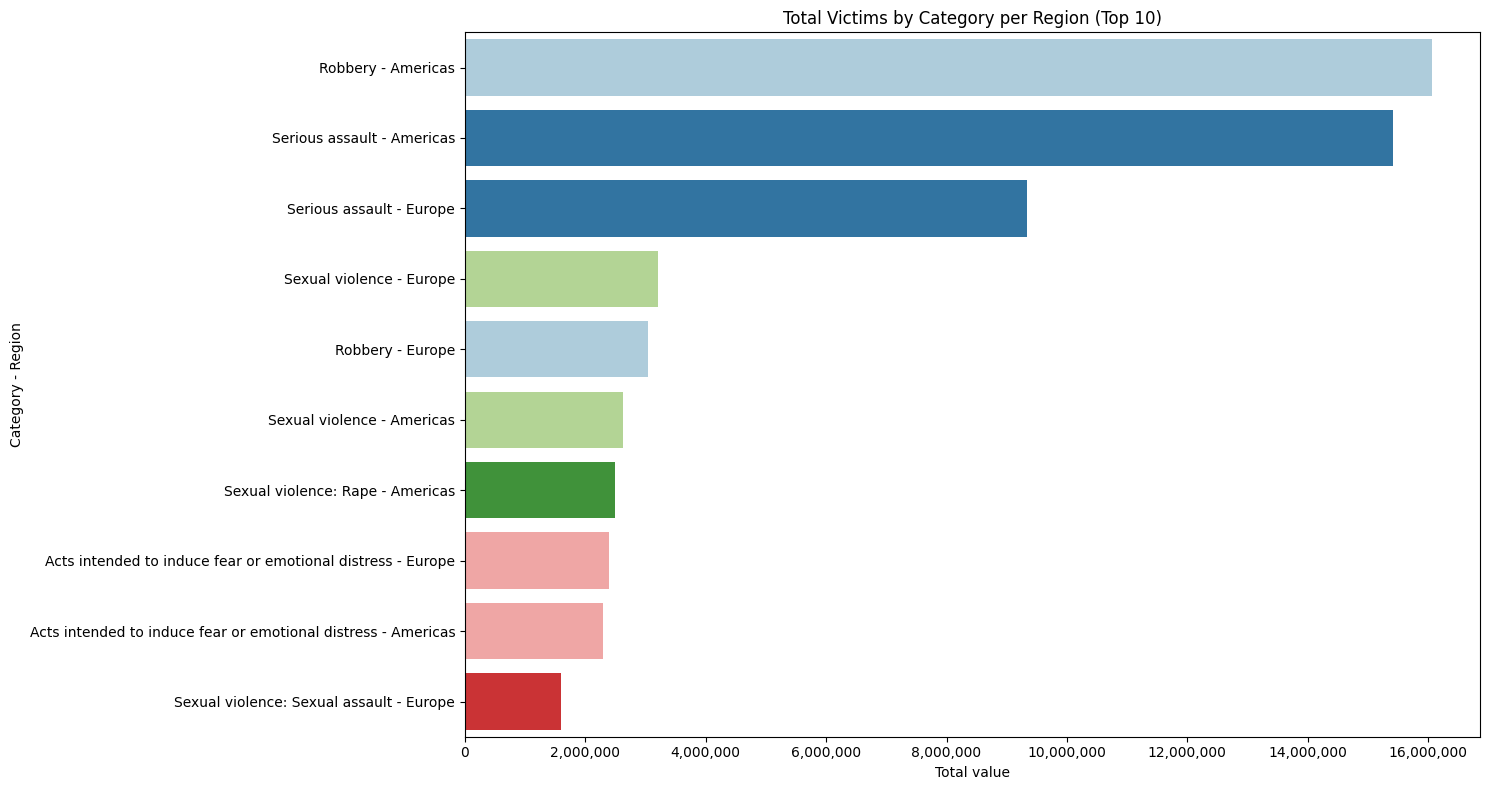

In [ ]:
# Display categories per region (top 10)
display(regcat_counts.head(10).style.format({'Total_Value': '{:,.0f}'}))

# bar plot
plt.figure(figsize=(15, 8))

# Prepare data for plotting the top 10 region-categories
plot_data = regcat_counts.head(10).copy()
plot_data['Category_Region'] = plot_data['Category'] + ' - ' + plot_data['Region']

ax = sns.barplot(
    data=plot_data,
    y= "Category_Region", # Use the new combined column for y-axis
    x= "Total_Value",
    hue="Category", # Keep hue for coloring by category
    palette="Paired",
    legend=False
)

# Format x-axis labels to display real numbers with commas
formatter = mticker.FormatStrFormatter('%1.0f') # Display as integer
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title("Total Victims by Category per Region (Top 10)")
plt.xlabel("Total value")
plt.ylabel("Category - Region")
plt.tight_layout()
plt.show()

## Display victims per country

In [ ]:
# Display victims per country
# Compute sum of 'value' per country
country_counts = (
    df.groupby(["Country"])["value"]
    .sum()
    .reset_index()
)
country_counts.columns = ["Country", "Total_Value"]

# Drop 0 in rows
country_counts = country_counts[country_counts['Total_Value'] != 0]

# Sort largest to smallest
country_counts = country_counts.sort_values(by="Total_Value", ascending=False)

# Print table of total value per subregion with comma formatting
display(country_counts.style.format({'Total_Value': '{:,.0f}'}))

,Country,Total_Value
20,Brazil,"15,894,035"
134,United States of America,"10,490,901"
131,United Kingdom (England and Wales),"6,192,831"
43,France,"5,939,318"
45,Germany,"2,810,387"
24,Canada,"2,614,010"
79,Mexico,"2,452,865"
29,Colombia,"2,389,175"
4,Argentina,"2,316,673"
25,Chile,"1,287,404"


## Top 10 countries with highest total victims

,Country,Total_Value
20,Brazil,"15,894,035"
134,United States of America,"10,490,901"
131,United Kingdom (England and Wales),"6,192,831"
43,France,"5,939,318"
45,Germany,"2,810,387"
24,Canada,"2,614,010"
79,Mexico,"2,452,865"
29,Colombia,"2,389,175"
4,Argentina,"2,316,673"
25,Chile,"1,287,404"


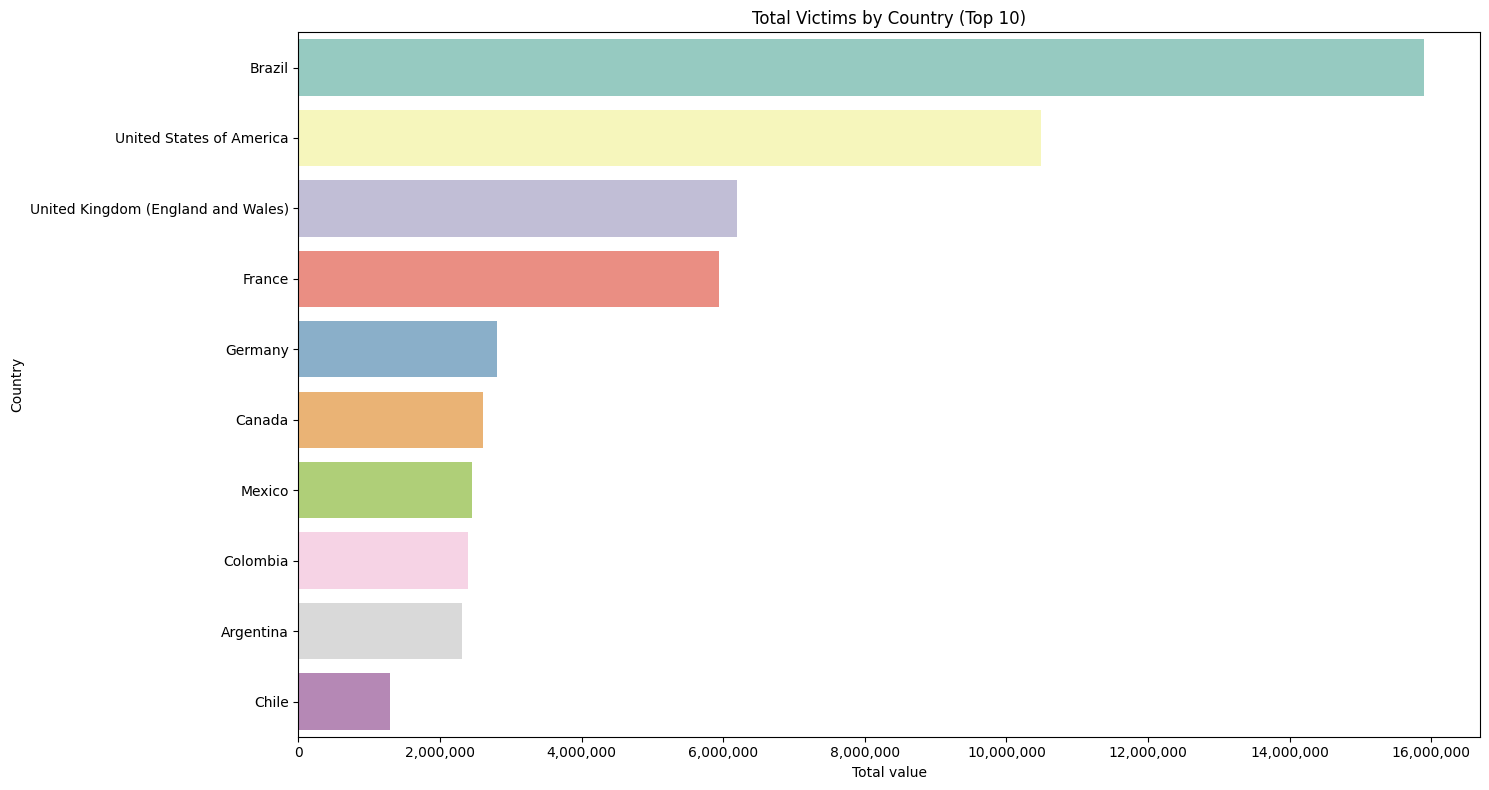

In [ ]:
# top 10 country
display(country_counts.head(10).style.format({'Total_Value': '{:,.0f}'}))

# bar plot
plt.figure(figsize=(15, 8))

# Prepare data for plotting the top 10 country
plot_data = country_counts.head(10)

# bar plot
ax = sns.barplot(
    data=plot_data,
    y= "Country",
    x= "Total_Value",
    hue="Country", # Keep hue for coloring by country
    palette="Set3",
    legend=False
)

# Format x-axis labels to display real numbers with commas
formatter = mticker.FormatStrFormatter('%1.0f') # Display as integer
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title("Total Victims by Country (Top 10)")
plt.xlabel("Total value")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

## Brazil - Total victims in each category

In [ ]:
# Display victims per category for Brazil

# Filter DataFrame for Brazil
df_brazil = df[df['Country'] == 'Brazil']

# Compute sum of 'value' per category for Brazil
brazil_category_counts = (
    df_brazil.groupby("Category")["value"]
    .sum()
    .reset_index()
)
brazil_category_counts.columns = ["Category", "Total_Value"]

# Sort largest to smallest
brazil_category_counts = brazil_category_counts.sort_values(by="Total_Value", ascending=False)


,Category,Total_Value
2,Robbery,"10,528,538"
3,Serious assault,"3,818,908"
7,Sexual violence: Rape,"581,794"
5,Sexual violence,"502,392"
0,Acts intended to induce fear or emotional distress: Cyber-related,"221,731"
8,Sexual violence: Sexual assault,"132,106"
6,Sexual violence: Other acts of sexual violence,"58,889"
1,Kidnapping,"29,981"
4,Sexual Exploitation,"19,696"


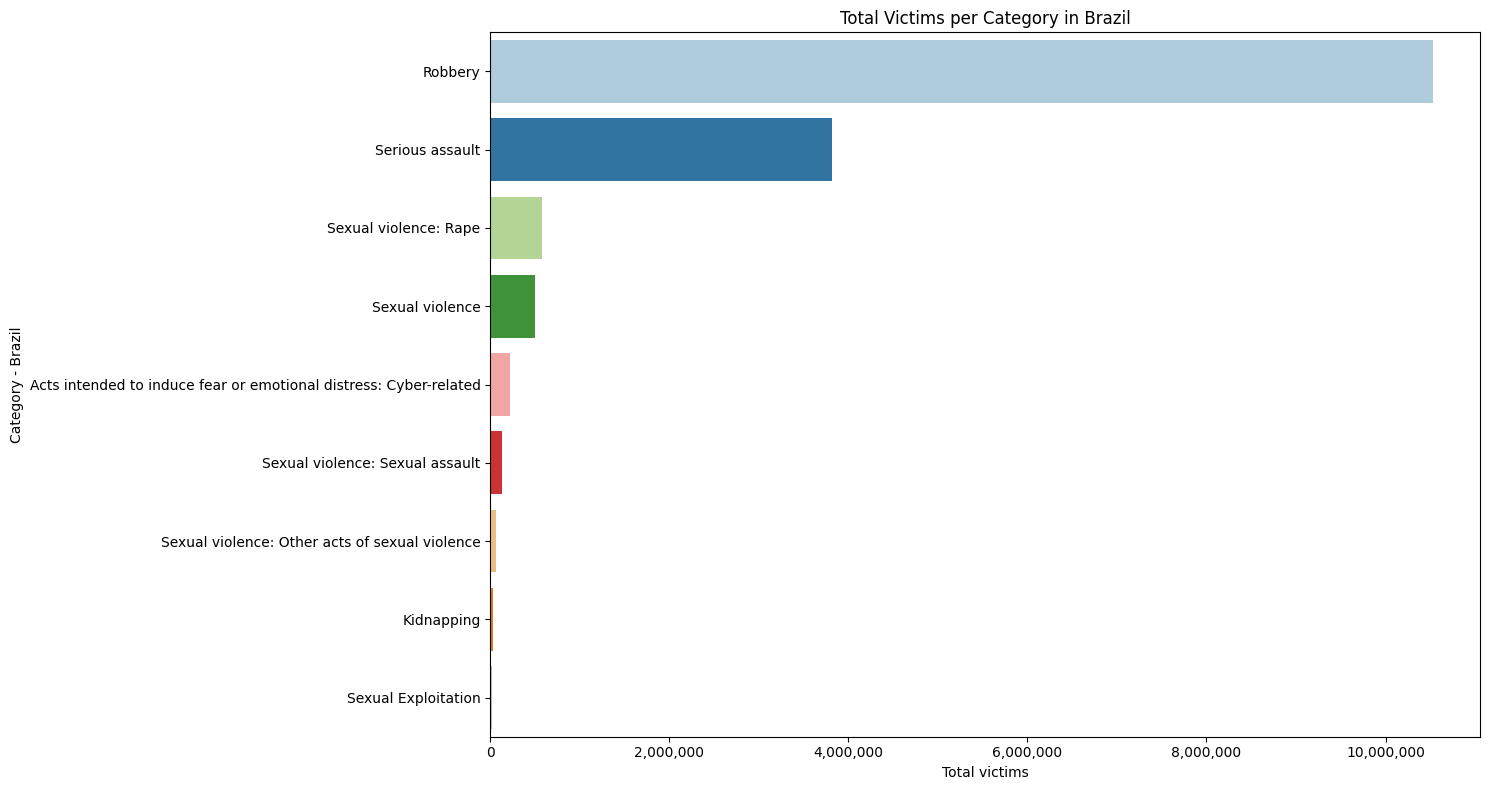

In [ ]:
# Print table of total value per category for Brazil with comma formatting
display(brazil_category_counts.style.format({'Total_Value': '{:,.0f}'}))

# bar plot
plt.figure(figsize=(15, 8))

# bar plot
ax = sns.barplot(
    data=brazil_category_counts,
    y= "Category",
    x= "Total_Value",
    hue="Category", # Keep hue for coloring by countey
    palette="Paired",
    legend=False
)

# Format x-axis labels to display real numbers with commas
formatter = mticker.FormatStrFormatter('%1.0f') # Display as integer
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title("Total Victims per Category in Brazil")
plt.xlabel("Total victims")
plt.ylabel("Category - Brazil")
plt.tight_layout()
plt.show()

## United States - Total victims in each category

In [ ]:
# Display victims per category for United States

# Filter DataFrame for United States
df_us = df[df['Country'] == 'United States of America']

# Compute sum of 'value' per category for United States
us_category_counts = (
    df_us.groupby("Category")["value"]
    .sum()
    .reset_index()
)
us_category_counts.columns = ["Category", "Total_Value"]

# Sort largest to smallest
us_category_counts = us_category_counts.sort_values(by="Total_Value", ascending=False)


,Category,Total_Value
2,Serious assault,"6,980,921"
1,Robbery,"2,198,002"
3,Sexual violence: Rape,"1,133,463"
0,Kidnapping,"178,515"


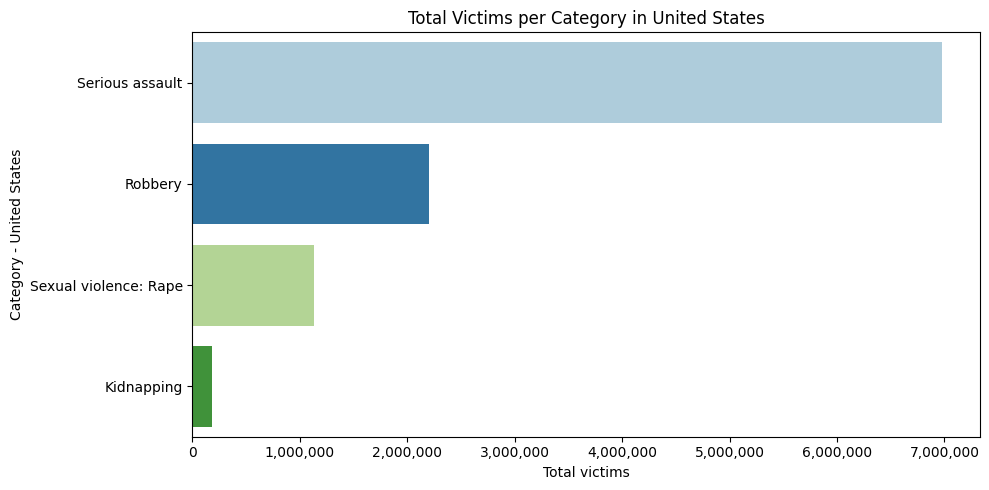

In [ ]:
# Print table of total value per category for United States with comma formatting
display(us_category_counts.style.format({'Total_Value': '{:,.0f}'}))

# bar plot
plt.figure(figsize=(10, 5))

# bar plot
ax = sns.barplot(
    data=us_category_counts,
    y= "Category",
    x= "Total_Value",
    hue="Category", # Keep hue for coloring by countey
    palette="Paired",
    legend=False
)

# Format x-axis labels to display real numbers with commas
formatter = mticker.FormatStrFormatter('%1.0f') # Display as integer
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title("Total Victims per Category in United States")
plt.xlabel("Total victims")
plt.ylabel("Category - United States")
plt.tight_layout()
plt.show()

## United Kingdom - Total victims in each category

In [ ]:
# Display victims per category for United Kingdom

# Filter DataFrame for United Kingdom
df_uk = df[df['Country'] == 'United Kingdom (England and Wales)']

# Compute sum of 'value' per category for United Kingdom
uk_category_counts = (
    df_uk.groupby("Category")["value"]
    .sum()
    .reset_index()
)
uk_category_counts.columns = ["Category", "Total_Value"]

# Sort largest to smallest
uk_category_counts = uk_category_counts.sort_values(by="Total_Value", ascending=False)

,Category,Total_Value
2,Serious assault,"3,649,844"
4,Sexual violence,"1,104,293"
1,Robbery,"513,523"
7,Sexual violence: Sexual assault,"404,189"
6,Sexual violence: Rape,"398,900"
5,Sexual violence: Other acts of sexual violence,"80,595"
0,Kidnapping,"37,224"
3,Sexual Exploitation,"4,263"


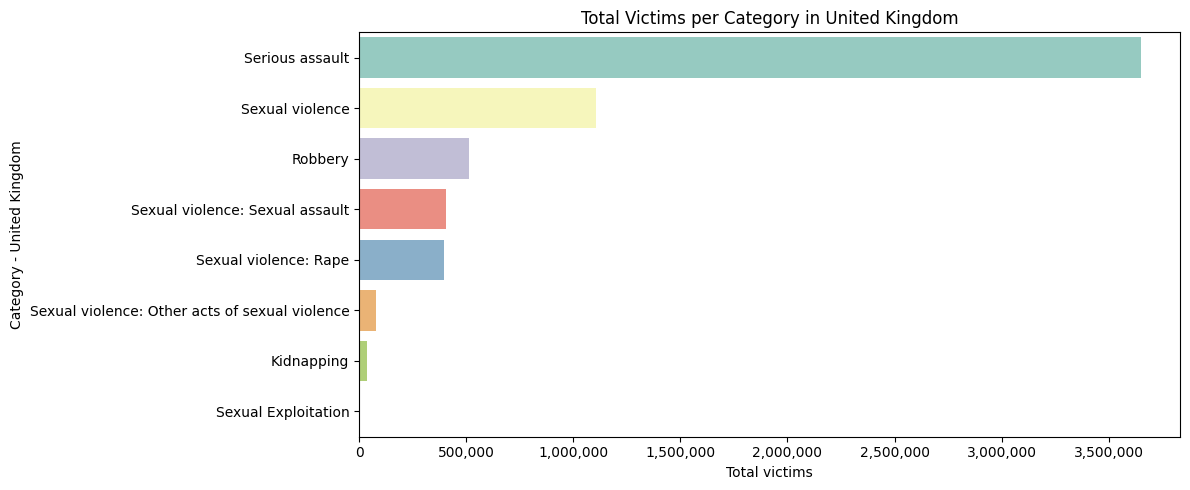

In [ ]:
# Print table of total value per category for United States with comma formatting
display(uk_category_counts.style.format({'Total_Value': '{:,.0f}'}))

# bar plot
plt.figure(figsize=(12, 5))

# bar plot
ax = sns.barplot(
    data=uk_category_counts,
    y= "Category",
    x= "Total_Value",
    hue="Category", # Keep hue for coloring by country
    palette="Set3",
    legend=False
)

# Format x-axis labels to display real numbers with commas
formatter = mticker.FormatStrFormatter('%1.0f') # Display as integer
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title("Total Victims per Category in United Kingdom")
plt.xlabel("Total victims")
plt.ylabel("Category - United Kingdom")
plt.tight_layout()
plt.show()

## France - Total victims in each category

In [ ]:
# Display victims per category for France

# Filter DataFrame for France
df_france = df[df['Country'] == 'France']

# Compute sum of 'value' per category for France
france_category_counts = (
    df_france.groupby("Category")["value"]
    .sum()
    .reset_index()
)
france_category_counts.columns = ["Category", "Total_Value"]

# Sort largest to smallest
france_category_counts = france_category_counts.sort_values(by="Total_Value", ascending=False)

,Category,Total_Value
4,Serious assault,"3,030,254"
0,Acts intended to induce fear or emotional distress,"799,991"
3,Robbery,"663,795"
6,Sexual violence,"578,296"
8,Sexual violence: Sexual assault,"320,928"
7,Sexual violence: Rape,"257,163"
1,Acts intended to induce fear or emotional distress: Cyber-related,"182,510"
5,Sexual Exploitation,"102,563"
2,Kidnapping,"3,818"


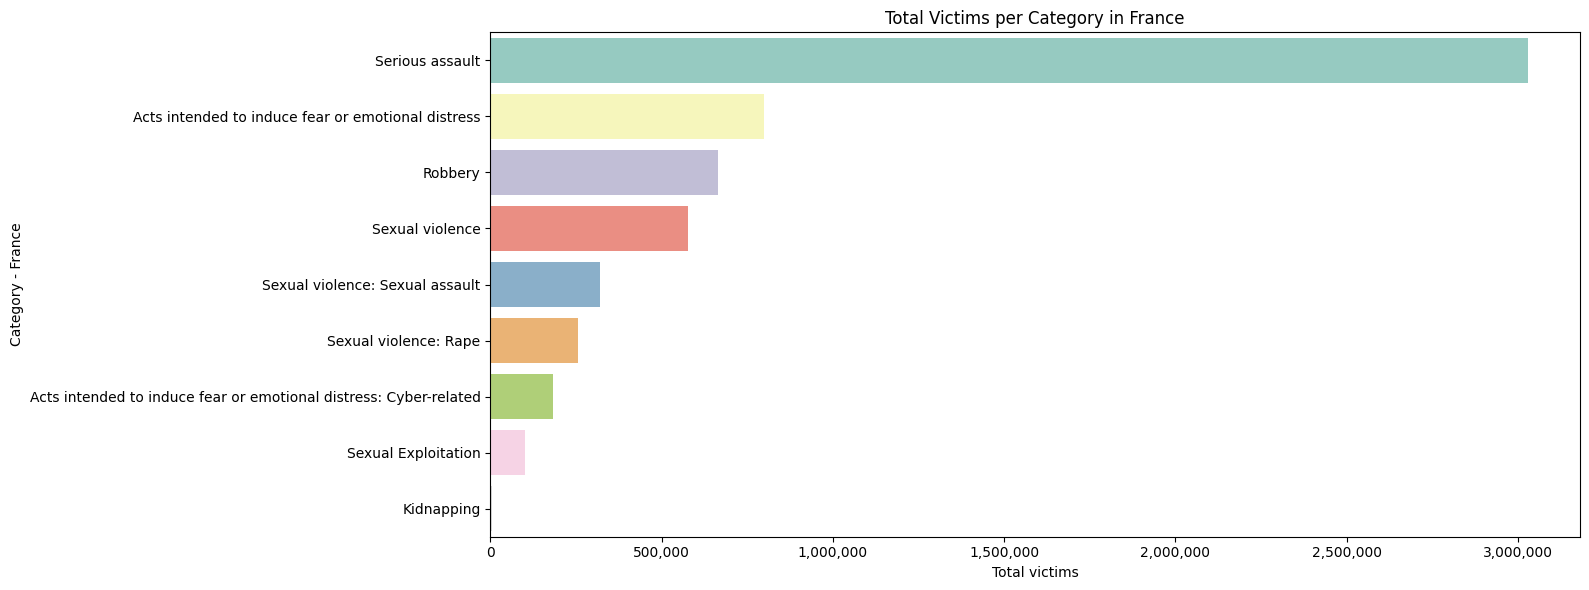

In [ ]:
# Print table of total value per category for United States with comma formatting
display(france_category_counts.style.format({'Total_Value': '{:,.0f}'}))

# bar plot
plt.figure(figsize=(16, 6))

# bar plot
ax = sns.barplot(
    data=france_category_counts,
    y= "Category",
    x= "Total_Value",
    hue="Category", # Keep hue for coloring by country
    palette="Set3",
    legend=False
)

# Format x-axis labels to display real numbers with commas
formatter = mticker.FormatStrFormatter('%1.0f') # Display as integer
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title("Total Victims per Category in France")
plt.xlabel("Total victims")
plt.ylabel("Category - France")
plt.tight_layout()
plt.show()

## Display victims per country and per each category

In [ ]:
# Display victims per country and per each category
# Compute sum of 'value' per category
ccat_counts = (
    df.groupby(["Category","Country"])["value"]
    .sum()
    .reset_index()
)
ccat_counts.columns = ["Category","Country", "Total_Value"]

# Drop 0 in rows
ccat_counts = ccat_counts[ccat_counts['Total_Value'] != 0]

# Sort largest to smallest
ccat_counts = ccat_counts.sort_values(by="Total_Value", ascending=False)

# Print table of total value per country with comma formatting
display(ccat_counts.style.format({'Total_Value': '{:,.0f}'}))

,Category,Country,Total_Value
249,Robbery,Brazil,"10,528,538"
481,Serious assault,United States of America,"6,980,921"
375,Serious assault,Brazil,"3,818,908"
478,Serious assault,United Kingdom (England and Wales),"3,649,844"
397,Serious assault,France,"3,030,254"
353,Robbery,United States of America,"2,198,002"
360,Serious assault,Argentina,"1,363,826"
399,Serious assault,Germany,"1,257,077"
383,Serious assault,Colombia,"1,232,950"
917,Sexual violence: Rape,United States of America,"1,133,463"


## Display top 10 categories - countries

,Category,Country,Total_Value
249,Robbery,Brazil,"10,528,538"
481,Serious assault,United States of America,"6,980,921"
375,Serious assault,Brazil,"3,818,908"
478,Serious assault,United Kingdom (England and Wales),"3,649,844"
397,Serious assault,France,"3,030,254"
353,Robbery,United States of America,"2,198,002"
360,Serious assault,Argentina,"1,363,826"
399,Serious assault,Germany,"1,257,077"
383,Serious assault,Colombia,"1,232,950"
917,Sexual violence: Rape,United States of America,"1,133,463"


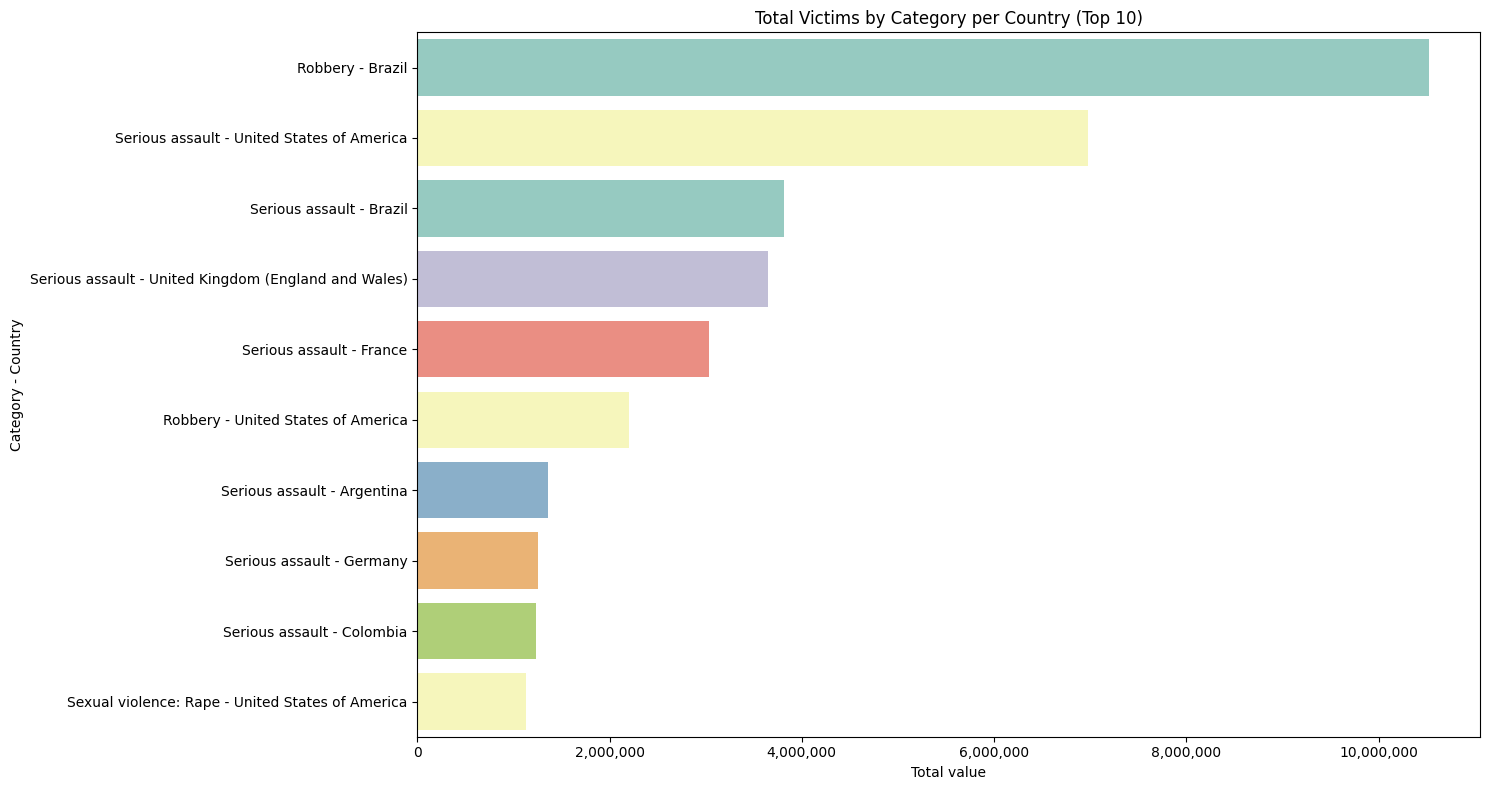

In [ ]:
# Display category - country (top 10)
display(ccat_counts.head(10).style.format({'Total_Value': '{:,.0f}'}))

# bar plot
plt.figure(figsize=(15, 8))

# Prepare data for plotting the top 10 categories - countries
plot_data = ccat_counts.head(10).copy()
plot_data['Category_Country'] = plot_data['Category'] + ' - ' + plot_data['Country']

ax = sns.barplot(
    data=plot_data,
    y= "Category_Country", # Use the new combined column for y-axis
    x= "Total_Value",
    hue="Country", # Keep hue for coloring by country
    palette="Set3",
    legend=False
)

# Format x-axis labels to display real numbers with commas
formatter = mticker.FormatStrFormatter('%1.0f') # Display as integer
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title("Total Victims by Category per Country (Top 10)")
plt.xlabel("Total value")
plt.ylabel("Category - Country")
plt.tight_layout()
plt.show()

## Animated visualization of top 10 countries by total victims over the years

In [ ]:
import pandas as pd
import plotly.express as px

# Ensure 'variable' column is numeric (representing the year)
df['variable'] = pd.to_numeric(df['variable'], errors='coerce')

# Drop rows where 'variable' is NaN after conversion
df_animated = df.dropna(subset=['variable']).copy()

# Group by year and country, summing 'value'
year_country_counts = (
    df_animated.groupby(['variable', 'Country'])['value']
    .sum()
    .reset_index()
)
year_country_counts.columns = ['Year', 'Country', 'Total_Victims']

# Sort for consistent ranking and select top 10 for each year
top_countries_over_time = year_country_counts.groupby('Year').apply(lambda x: x.nlargest(10, 'Total_Victims')).reset_index(drop=True)

display(top_countries_over_time)

/tmp/ipykernel_1239/4201589129.py:19: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,Year,Country,Total_Victims
0,2016,Brazil,2235881
1,2016,United States of America,1268200
2,2016,United Kingdom (England and Wales),739863
3,2016,France,473903
4,2016,South Africa,469301
...,...,...,...
85,2024,Canada,217276
86,2024,Colombia,165656
87,2024,Australia,136679
88,2024,Spain,134305


In [ ]:
# Create animated bar chart using Plotly Express
fig = px.bar(
    top_countries_over_time,
    x='Total_Victims',
    y='Country',
    animation_frame='Year',
    animation_group='Country',
    color='Country',
    hover_name='Country',
    orientation='h',
    title='Top 10 Countries by Total Victims Over Time',
    labels={'Total_Victims': 'Total Victims', 'Country': 'Country'},
    range_x=[0, top_countries_over_time['Total_Victims'].max() * 1.1]
)

# Adjust layout and animation speed
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 1000 # Set animation speed
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 500

fig.update_layout(yaxis={'categoryorder':'total ascending'}) # Keep the order consistent

fig.show()

## Animated visualization of top 5 categories with total victims over the years

In [ ]:
# Group by counts and categories, summing 'value'
year_categories_counts = (
    df_animated.groupby(['variable', 'Category'])['value']
    .sum()
    .reset_index()
)
year_categories_counts.columns = ['Year', 'Category', 'Total_Victims']

# Sort for consistent ranking and select top 5 for each year
top_categories_over_time = year_categories_counts.groupby('Year').apply(lambda x: x.nlargest(5, 'Total_Victims')).reset_index(drop=True)

display(top_categories_over_time)

/tmp/ipykernel_1239/370803472.py:10: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,Year,Category,Total_Victims
0,2016,Serious assault,3440039
1,2016,Robbery,3044141
2,2016,Sexual violence,642457
3,2016,Sexual violence: Rape,399918
4,2016,Acts intended to induce fear or emotional dist...,393173
5,2017,Serious assault,3517520
6,2017,Robbery,3139478
7,2017,Sexual violence,676270
8,2017,Sexual violence: Rape,440444
9,2017,Acts intended to induce fear or emotional dist...,410862


In [ ]:
# Create animated bar chart using Plotly Express
fig = px.bar(
    top_categories_over_time,
    x='Total_Victims',
    y='Category',
    animation_frame='Year',
    animation_group='Category',
    color='Category',
    hover_name='Category',
    orientation='h',
    title='Top 5 Categories by Total Victims Over Time',
    labels={'Total_Victims': 'Total Victims', 'Category': 'Category'},
    range_x=[0, top_categories_over_time['Total_Victims'].max() * 1.1]
)

# Adjust layout and animation speed
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 1000 # Set animation speed
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 500

fig.update_layout(yaxis={'categoryorder':'total ascending'}) # Keep the order consistent

fig.show()